# Linear Regression with Multi-dimensional Data

This notebook demonstrates how to implement linear regression for multi-dimensional data (multiple features and multiple outputs) from scratch using NumPy. We will:
- Define the mathematical formulation
- Implement the forward pass, cost function, and gradient
- Train the model using gradient descent
- Handle bias terms

All code is explained step by step.

## Problem Formulation

We want to fit a linear model to data with multiple features and multiple outputs. The model is:

$$
\hat{Y} = XW
$$

where:
- $X$ is the input matrix of shape $(n, d)$ (n samples, d features)
- $W$ is the weight matrix of shape $(d, m)$ (d features, m outputs)
- $\hat{Y}$ is the predicted output of shape $(n, m)$
- $Y$ is the true output of shape $(n, m)$

The loss function (with L2 regularization) is:

$$
J(W) = \| XW - Y \|_2^2 + \lambda \|W\|_2^2
$$

where $\lambda$ is the regularization parameter.

### Gradient Calculation

The gradient of the loss function with respect to $W$ is:

$$
\nabla_W J = 2 X^T (XW - Y) + 2 \lambda W
$$

We will use this gradient to update the weights during training.

In [7]:
import numpy as np

class LinearRegressionMD:
    def __init__(self, num_iters: int, lr: float, regularization_term: float = 0.0):
        self.num_iters = num_iters
        self.lr = lr
        self.regularization_term = regularization_term
        self.w = None
        self.b = None
        self.loss_history = []
        
    def fit(self, x_train, y_train): 
        if y_train.ndim == 1:
            y_train = y_train.reshape(-1, 1)
        
        n_samples, n_features = x_train.shape
        n_outputs = y_train.shape[1]
        
        # Initialize weights and bias
        self.w = np.zeros((n_features, n_outputs))
        self.b = np.zeros((n_outputs,))
        
        for i in range(self.num_iters):
            # Forward pass
            y_pred = x_train @ self.w + self.b
            
            # Loss (with regularization)
            loss = (1 / n_samples) * np.sum((y_pred - y_train)**2) + self.regularization_term * np.sum(self.w**2)
            self.loss_history.append(loss)
            
            # Gradients
            error = y_pred - y_train
            dw = (2 / n_samples) * (x_train.T @ error) + 2 * self.regularization_term * self.w
            db = (2 / n_samples) * np.sum(error, axis=0)
            
            # Update
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            if i % 100 == 0:
                print(f"Iteration {i}: Loss = {loss:.4f}")
                
    def predict(self, x_test):
        return x_test @ self.w + self.b.reshape(1, -1)


Iteration 0: Loss = 1.1037
Iteration 100: Loss = 1.0031
Iteration 200: Loss = 0.9143
Iteration 300: Loss = 0.8358
Iteration 400: Loss = 0.7666
Iteration 500: Loss = 0.7054
Iteration 600: Loss = 0.6514
Iteration 700: Loss = 0.6037
Iteration 800: Loss = 0.5615
Iteration 900: Loss = 0.5243


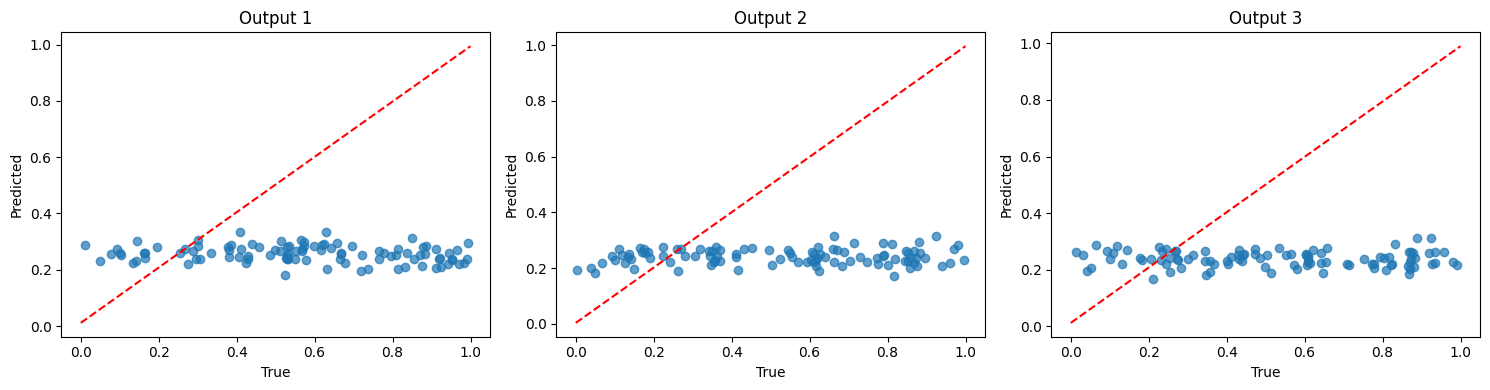

In [9]:
import matplotlib.pyplot as plt

# Generate random data
num_samples = 100
num_features = 8
num_outputs = 3
x_train = np.random.rand(num_samples, num_features)
y_train = np.random.rand(num_samples, num_outputs)

# Train the model
model = LinearRegressionMD(num_iters=1000, lr=0.0001, regularization_term=0.01)
model.fit(x_train=x_train, y_train=y_train)

# Predict
y_pred = model.predict(x_train)

# Plot true vs predicted for each output
fig, axes = plt.subplots(1, num_outputs, figsize=(15, 4))
for i in range(num_outputs):
    axes[i].scatter(y_train[:, i], y_pred[:, i], alpha=0.7)
    axes[i].plot([y_train[:, i].min(), y_train[:, i].max()],
                 'r--')
    axes[i].set_xlabel('True')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'Output {i+1}')
plt.tight_layout()
plt.show()